<div style="
    background: linear-gradient(135deg, #7b1113, #1f1c18);
    padding: 35px;
    border-radius: 20px;
    text-align: center;
    color: white;
    font-family: Arial;
">

<img src="https://cdn-icons-png.flaticon.com/512/2966/2966486.png" 
width="110">

<h1 style="
    margin-top:15px;
    font-size:38px;
">
Image Classification with CNN for Malaria Data
</h1>

<h2 style="
    text-align:center;
    margin-top:10px;
    color:#ffd166;
    font-weight:normal;
">
CNN with Custom Images
</h2>

<p style="
    font-size:18px;
    margin-top:18px;
">
Deep Learning Based Classification of Parasitized and Uninfected Cell Images
</p>

</div>


<p style="
    font-size:18px;
    margin-top:15px;
">
</div>

<div style="font-family:Arial; line-height:1.8; font-size:16px;">
<h2>Project Workflow</h2>
<ol>
    <li>Import required libraries</li>
    <li>Load malaria cell image dataset</li>
    <li>Visualize sample images</li>
    <li>Preprocess image data</li>
    <li>Apply data augmentation</li>
    <li>Build a custom CNN model</li>
    <li>Train and evaluate the CNN model</li>
    <li>Apply transfer learning models</li>
    <li>Compare model performances</li>
    <li>Interpret the results</li>
</ol>
</div>

In [1]:
import os

print(os.getcwd())

C:\Users\zbeun\Documents\Yapay Zeka Kursu\MALARİA


In [2]:
print(os.listdir())

['.ipynb_checkpoints', 'cell_images', 'cell_images.zip', 'Image Classification with CNN for Malaria Data.ipynb']


In [3]:
dataset_path = r"cell_images\cell_images"
print(os.listdir(dataset_path))

['Parasitized', 'Uninfected']


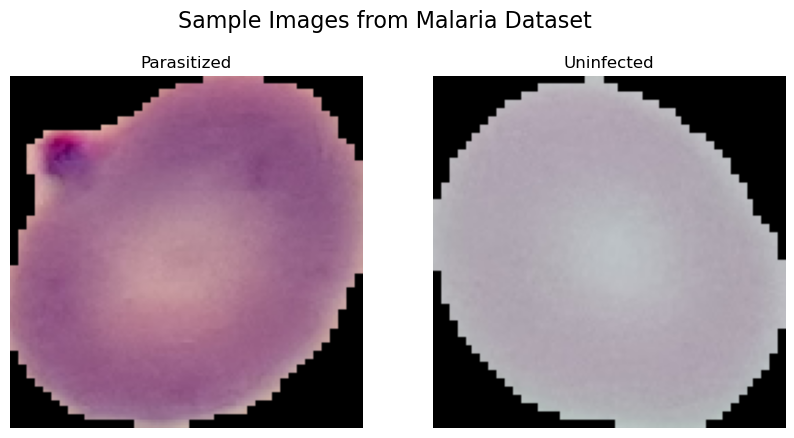

In [4]:
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

dataset_path = r"cell_images\cell_images"

classes = ["Parasitized", "Uninfected"]

plt.figure(figsize=(10, 5))

for i, cls in enumerate(classes):
    cls_path = os.path.join(dataset_path, cls)
    
    image_files = [
        file for file in os.listdir(cls_path)
        if file.lower().endswith((".png", ".jpg", ".jpeg"))    ]
    
    img_name = random.choice(image_files)
    img_path = os.path.join(cls_path, img_name)
    
    img = load_img(img_path, target_size=(128, 128))
    
    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Sample Images from Malaria Dataset", fontsize=16)
plt.show()

#### Data Preprocessing

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 128
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary",
    subset="training")

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary",
    subset="validation")

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


In [6]:
### Custom CNN Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"])

model.summary()

C:\Users\zbeun\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 240s 346ms/step - accuracy: 0.8532 - loss: 0.3408 - val_accuracy: 0.9289 - val_loss: 0.1705
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 235s 341ms/step - accuracy: 0.9477 - loss: 0.1699 - val_accuracy: 0.9436 - val_loss: 0.1709
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 230s 333ms/step - accuracy: 0.9549 - loss: 0.1512 - val_accuracy: 0.9434 - val_loss: 0.1810
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 229s 333ms/step - accuracy: 0.9542 - loss: 0.1492 - val_accuracy: 0.9481 - val_loss: 0.1565
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 231s 335ms/step - accuracy: 0.9546 - loss: 0.1425 - val_accuracy: 0.9445 - val_loss: 0.1758
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 234s 339ms/step - accuracy: 0.9556 - loss: 0.1378 - val_accuracy: 0.9450 - val_loss: 0.1613
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 233s 338ms/step - accuracy: 0.9564 - loss: 0.1390 - val_accuracy: 0.9457 - val_loss: 0.1542
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 264s 383ms/step - accuracy: 0.9565 -

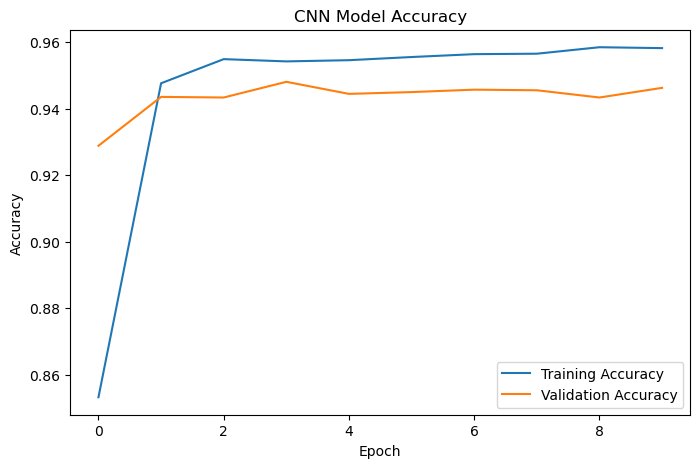

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

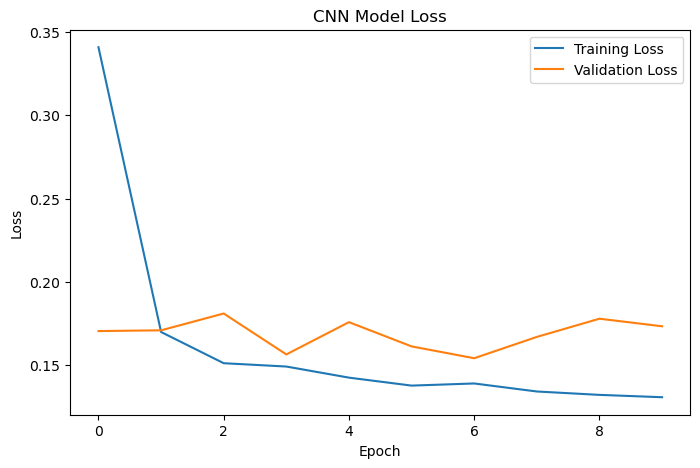

In [9]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

##### Accuracy Grafiği Yorumu

Eğitim ve doğrulama doğruluk eğrileri, CNN modelinin sıtma hücre görüntülerinden önemli özellikleri başarılı bir şekilde öğrendiğini göstermektedir.

Doğruluk değerlerindeki artış, modelin enfekte ve sağlıklı hücreleri ayırt etme becerisinin eğitim süreci boyunca geliştiğini göstermektedir.

Validation accuracy değerinin training accuracy değerine yakın olması, modelin aşırı öğrenme (overfitting) yapmadan iyi genelleme gerçekleştirdiğini göstermektedir.

#### ResNet50

In [10]:
import os
import random

sample_class = "Parasitized"

sample_path = os.path.join(dataset_path, sample_class)

sample_image = random.choice(os.listdir(sample_path))

img_path = os.path.join(sample_path, sample_image)

print(img_path)

cell_images\cell_images\Parasitized\C183P144NThinF_IMG_20151201_223208_cell_122.png


In [11]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

img = load_img(img_path, target_size=(224,224))

x = img_to_array(img)

x = np.expand_dims(x, axis=0)

print(x.shape)

(1, 224, 224, 3)


In [12]:
import os
import random
import numpy as np
import keras
from keras.utils import load_img, img_to_array

dataset_path = r"cell_images\cell_images"

sample_class = "Parasitized"
sample_folder = os.path.join(dataset_path, sample_class)

image_files = [
    file for file in os.listdir(sample_folder)
    if file.lower().endswith((".png", ".jpg", ".jpeg"))]

img_name = random.choice(image_files)
img_path = os.path.join(sample_folder, img_name)

print(img_path)

cell_images\cell_images\Parasitized\C180P141NThinF_IMG_20151201_164714_cell_182.png


In [13]:
from keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions

resnet_model = ResNet50(weights="imagenet")

img = load_img(img_path, target_size=(224, 224))
x = img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

preds = resnet_model.predict(x)

print("Predicted:", decode_predictions(preds, top=3)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted: [('n03884397', 'panpipe', np.float32(0.8196852)), ('n03028079', 'church', np.float32(0.10739469)), ('n03908714', 'pencil_sharpener', np.float32(0.026784327))]


In [14]:
from keras.applications.vgg16 import VGG16, preprocess_input

vgg16_model = VGG16(weights="imagenet", include_top=False)

img = load_img(img_path, target_size=(224, 224))
x = img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

features = vgg16_model.predict(x)

print("Feature shape:", features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step
Feature shape: (1, 7, 7, 512)


In [15]:
from keras.applications.vgg19 import VGG19, preprocess_input
from keras.models import Model

base_model = VGG19(weights="imagenet")

vgg19_feature_model = Model(
    inputs=base_model.input,
    outputs=base_model.get_layer("block4_pool").output)

img = load_img(img_path, target_size=(224, 224))
x = img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

block4_pool_features = vgg19_feature_model.predict(x)

print("Block4 pool feature shape:", block4_pool_features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
Block4 pool feature shape: (1, 14, 14, 512)


### Transfer Learning

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

transfer_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2)

train_transfer = transfer_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary",
    subset="training")

val_transfer = transfer_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary",
    subset="validation")

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


In [17]:
## VGG16 Transfer Learning

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

vgg16_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3))

vgg16_base.trainable = False

vgg16_model = Sequential([
    vgg16_base,
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")])

vgg16_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"])

vgg16_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 3,211,521 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
#### VGG16 Training
vgg16_history = vgg16_model.fit(
    train_transfer,
    validation_data=val_transfer,
    epochs=5)

In [ ]:
### ResNet50 Transfer Learning
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3))

resnet_base.trainable = False

x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

resnet_model = Model(inputs=resnet_base.input, outputs=output)

resnet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"])

resnet_model.summary()

### ResNet50 Training

In [ ]:
resnet_history = resnet_model.fit(
    train_transfer,
    validation_data=val_transfer,
    epochs=5)

In [ ]:
cnn_acc = max(history.history["val_accuracy"])
vgg16_acc = max(vgg16_history.history["val_accuracy"])
resnet_acc = max(resnet_history.history["val_accuracy"])

model_results = {
    "Model": ["Custom CNN", "VGG16", "ResNet50"],
    "Validation Accuracy": [cnn_acc, vgg16_acc, resnet_acc]}

import pandas as pd

results_df = pd.DataFrame(model_results)
results_df

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Validation Accuracy"])
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1)
plt.show()